# Elmer mesh directories, FEBio models and FEBio results

Three formats from two open-source FEM codes, all new in v16.2.0:

- **Elmer mesh directories** are what ElmerSolver reads: a *directory* of `mesh.header`, `mesh.nodes`, `mesh.elements`, `mesh.boundary` and `mesh.names`. Bodies and boundaries become named regions, ElmerGrid's partitions are merged back into one mesh, and the writer regenerates each boundary element's parents. A directory has no extension, so meshio++ now recognises one **by the files it holds**: `read("box")` needs no format.
- **FEBio `.feb`** is the input of FEBio, the biomechanics solver. meshio++ reads the mesh of spec 2.5, 3.0 and 4.0 files, sets and surfaces included, and writes spec 4.0.
- **FEBio `.xplt`** is FEBio's binary results file: the mesh once, then one state per saved time, optionally zlib-compressed. meshio++ reads it one state at a time, so a run converts to a `.vtu` sequence.

The files are in `tests/python/meshes/elmer/` and `tests/python/meshes/febio/`. The `.xplt` files are FEBio 4.12's own output for the models next to them.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def to_grid(mesh, cell_data=None, point_data=None):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4')]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460)):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=True, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector((-1.0, -1.4, 0.45), viewup=(0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(1.0)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def show_files(directory, names=None, head=6):
    '''Print the first lines of each file of a directory-shaped mesh.'''
    for name in names or sorted(os.listdir(directory)):
        with open(os.path.join(directory, name)) as fh:
            lines = fh.read().splitlines()
        print(f'--- {name} ({len(lines)} lines)')
        for line in lines[:head]:
            print('   ', line)


## An Elmer mesh directory

`tet10_two_bodies` holds two quadratic tetrahedra in two bodies, `left` and `right`, and three boundaries: an outer face, the interface between the tets (a boundary element with **two** parents), and a point condition with none (`101`). It is read with no format: the directory is sniffed by its `mesh.header`. Bulk and boundary elements are separate cell blocks, and bodies and boundaries are cell regions tagged with their Elmer ids.

In [2]:
box = path('elmer', 'tet10_two_bodies')
print('sniffed as:', mp.sniff_format(box))
show_files(box, ['mesh.header', 'mesh.elements', 'mesh.boundary', 'mesh.names'])
mesh = mp.read(box)
print(mesh)
for r in mesh.regions:
    print(f'{r.name:10s} {r.kind:5s} dim {r.dim}  tag {r.tag}  cells {r.entries.tolist()}')

sniffed as: elmer
--- mesh.header (5 lines)
    14     2      3     
    3     
    101    1     
    306    2     
    510    2     
--- mesh.elements (2 lines)
    1 1 510 1 2 3 4 5 6 7 8 9 10
    2 2 510 2 3 4 11 6 10 9 12 13 14
--- mesh.boundary (3 lines)
    1 2 1 0 306 1 2 4 5 9 8
    2 3 1 2 306 2 3 4 6 10 9
    3 4 0 0 101 1
--- mesh.names (7 lines)
    ! ----- names for bodies -----
    $ left = 1
    $ right = 2
    ! ----- names for boundaries -----
    $ outer = 2
    $ interface = 3
<meshio++ mesh object>
  Number of points: 14
  Number of cells:
    tetra10: 2
    triangle6: 2
    vertex: 1
  Cell sets: corner, interface, left, outer, right
corner     cell  dim 0  tag 4  cells [4]
interface  cell  dim 2  tag 3  cells [3]
left       cell  dim 3  tag 1  cells [0]
outer      cell  dim 2  tag 2  cells [2]
right      cell  dim 3  tag 2  cells [1]


## A quadratic beam, written for ElmerSolver

A 12 × 2 × 2 hexahedral beam, elevated to `hexahedron20`, split into two bodies and clamped at one end by a **side** region, the faces of the `x = 0` cells. The writer puts the bricks in `mesh.elements`, turns the side region's faces into `408` boundary elements, and regenerates each one's parent from the mesh.

Elmer's `820` brick numbers its nodes differently from meshio++'s (VTK's): the four vertical mid-edge nodes (Elmer's 13–16) come before the top ring (17–20), where VTK puts them last; the `827` brick also reorders its face centres. The first element's row, in both orders, shows the permutation the writer applies. It was pinned against ElmerSolver's own `elements.def`, and meshes written this way solve the heat equation in ElmerSolver to the same answer as ElmerGrid's own conversions (checked outside this notebook).

In [3]:
beam = mp.convert_cells(mp.grid((12, 2, 2), spacing=(0.5, 0.5, 0.5)), mode='elevate')
beam = mp.Mesh(beam.points, beam.cells)
print('cell type after elevate:', beam.cells[0].type)
n = len(beam.cells[0].data)
centres = beam.points[beam.cells[0].data[:, :8]].mean(axis=1)
left = np.flatnonzero(centres[:, 0] < 3.0)
right = np.flatnonzero(centres[:, 0] >= 3.0)
end = np.flatnonzero(centres[:, 0] < 0.5)
beam.regions = [
    mp.Region('soft', 'cell', left, dim=3, tag=1),
    mp.Region('stiff', 'cell', right, dim=3, tag=2),
    # hexahedron face 0 is the x- face (detail/cell_faces.hpp)
    mp.Region('clamped', 'side', np.column_stack([end, np.zeros_like(end)]), dim=2, tag=5),
]
out = os.path.join(TMP, 'beam')
mp.write(out, beam, file_format='elmer')
show_files(out, ['mesh.header', 'mesh.boundary', 'mesh.names'], head=4)
with open(os.path.join(out, 'mesh.elements')) as fh:
    first = fh.readline().split()
print('meshio++ row of element 1 (1-based):', (beam.cells[0].data[0] + 1).tolist())
print('Elmer row of element 1            :', [int(v) for v in first[3:]])
back = mp.read(out)
print([(c.type, len(c.data)) for c in back.cells])
print([(r.name, r.kind, r.tag, len(r.entries)) for r in back.regions])

cell type after elevate: hexahedron20
--- mesh.header (4 lines)
    381    48     4     
    2     
    408    4     
    820    48    
--- mesh.boundary (4 lines)
    1 5 1 0 408 1 40 53 14 126 125 129 121
    2 5 13 0 408 14 53 66 27 129 223 225 220
    3 5 25 0 408 40 79 92 53 285 284 288 125
    4 5 37 0 408 53 92 105 66 288 346 348 223
--- mesh.names (6 lines)
    ! Written by meshio++ v16.1.0
    ! ----- names for bodies -----
    $ soft = 1
    $ stiff = 2
meshio++ row of element 1 (1-based): [1, 2, 15, 14, 40, 41, 54, 53, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129]
Elmer row of element 1            : [1, 2, 15, 14, 40, 41, 54, 53, 118, 119, 120, 121, 126, 127, 128, 129, 122, 123, 124, 125]
[('hexahedron20', 48), ('quad8', 4)]
[('clamped', 'cell', 5, 4), ('soft', 'cell', 1, 24), ('stiff', 'cell', 2, 24)]


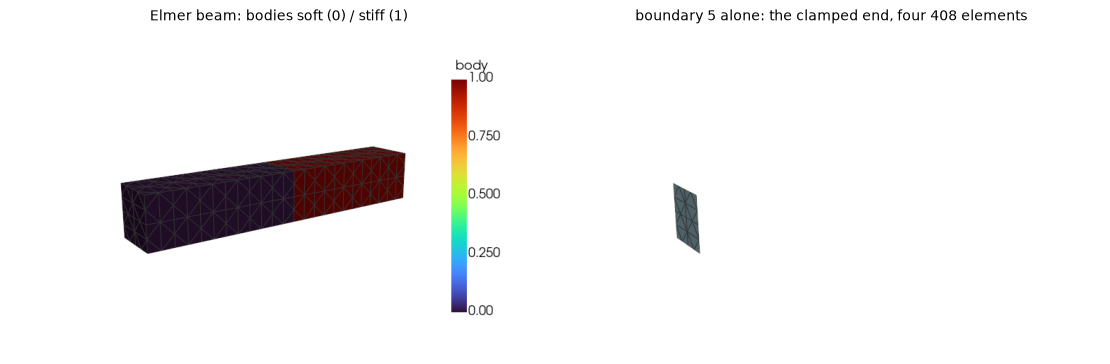

In [4]:
gallery([
    (to_grid(back, cell_data={'body': region_array(back, ['soft', 'stiff'])}), 'body', 'Elmer beam: bodies soft (0) / stiff (1)', (0, 1)),
    (to_grid(mp.Mesh(back.points, back.cells[1:])), None, 'boundary 5 alone: the clamped end, four 408 elements', None),
])

## Partitioned meshes

`ElmerGrid 2 2 box -partition 2 1 1 -halo` writes `box/partitioning.2/part.1.*` and `part.2.*`: each part lists the nodes it uses (shared nodes appear in both), and with `-halo` a part also carries copies of its neighbours' elements, written `id/owner`. Reading merges the parts back into one mesh, each shared node and halo element once, and labels every cell with its part in `partition:part`, the key the [partition](../../doc/partition.md) operation writes. `piece=` reads one part alone, halo copies included.

In [5]:
parts = path('elmer', 'partitioned')
print(sorted(os.listdir(os.path.join(parts, 'partitioning.2'))))
merged = mp.read(parts)
print([(c.type, len(c.data)) for c in merged.cells], [a.tolist() for a in merged.cell_data['partition:part']])
second = mp.read(parts, piece=1)
print('part 2 alone:', [(c.type, len(c.data)) for c in second.cells], '(its own triangle and the halo copy)')

['part.1.boundary', 'part.1.elements', 'part.1.header', 'part.1.nodes', 'part.1.shared', 'part.2.boundary', 'part.2.elements', 'part.2.header', 'part.2.nodes', 'part.2.shared']
[('triangle', 2), ('line', 2)] [[0, 1], [0, 1]]
part 2 alone: [('triangle', 2), ('line', 1)] (its own triangle and the halo copy)


## An FEBio model file

`all_elements_v40.feb` is a spec-4.0 file with one element of every solid type, a shell, node sets (one written as the range `1:10`), an element set, two surfaces, an edge, a discrete spring set and `<MeshData>`. FEBio 4.12 reads it. Each `<Elements>` block becomes a cell block and a cell region, tagged with its domain's material id.

- The surface `hex_base` lies on a face of the `hex8`, so it is a **side** region, matched by its corner nodes.
- The surface `floating` lies on no solid face, so it becomes its own `triangle` block.
- `hex27` goes through the `"febio"` node-order table: FEBio numbers its mid-height face centres y−, x+, y+, x−.

<meshio++ mesh object>
  Number of points: 112
  Number of cells:
    tetra: 1
    tetra10: 1
    wedge: 1
    wedge15: 1
    pyramid: 1
    pyramid13: 1
    hexahedron: 1
    hexahedron20: 1
    hexahedron27: 1
    quad: 1
    triangle: 1
    line: 1
    line: 1
  Point sets: ShellNodes, SolidNodes, first_ten, hex_bottom
  Cell sets: floating, hex_edge, part_hex20, part_hex27, part_hex8, part_penta15, part_penta6, part_pyra13, part_pyra5, part_quad4, part_tet10, part_tet4, quadratic, springs
  Side sets: hex_base
  Point data: temperature
  Cell data: fiber
floating      cell  dim  2 tag  -1  [10]
hex_edge      cell  dim  1 tag  -1  [11]
part_hex20    cell  dim  3 tag   8  [7]
part_hex27    cell  dim  3 tag   9  [8]
part_hex8     cell  dim  3 tag   7  [6]
part_penta15  cell  dim  3 tag   4  [3]
part_penta6   cell  dim  3 tag   3  [2]
part_pyra13   cell  dim  3 tag   6  [5]
part_pyra5    cell  dim  3 tag   5  [4]
part_quad4    cell  dim  2 tag  10  [9]
part_tet10    cell  dim  3 tag   

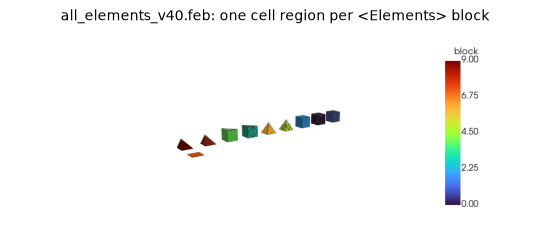

In [6]:
feb = mp.read(path('febio', 'all_elements_v40.feb'))
print(feb)
for r in feb.regions:
    if r.kind != 'point':
        print(f'{r.name:13s} {r.kind:5s} dim {r.dim:2d} tag {r.tag:3d}  {r.entries.tolist()}')
print('temperature (NaN outside hex_bottom):', feb.point_data['temperature'][feb.cells[6].data[0][:6]])
blocks = [r.name for r in feb.regions if r.name.startswith('part_')]
gallery([(to_grid(feb, cell_data={'block': region_array(feb, blocks)}), 'block', 'all_elements_v40.feb: one cell region per <Elements> block', None)], ncols=1, size=(1100, 420))

Written back, the beam from above becomes a spec-4.0 file. The writer adds one placeholder material per domain, because FEBio refuses a domain without one; replace them before running. The side region becomes a `<Surface>`. The file can be imported into FEBio Studio or pulled into a model with `<Mesh from="beam.feb"/>`. meshio++ checked that route against FEBio 4.12, which reproduced the original displacements.

In [7]:
mp.write(os.path.join(TMP, 'beam.feb'), beam)
with open(os.path.join(TMP, 'beam.feb')) as fh:
    text = fh.read().splitlines()
for line in text[:12] + ['...'] + [l for l in text if 'Surface' in l or 'Domain' in l]:
    print(line[:110])
again = mp.read(os.path.join(TMP, 'beam.feb'))
print([(r.name, r.kind, len(r.entries)) for r in again.regions])

<?xml version="1.0" encoding="ISO-8859-1"?>
<febio_spec version="4.0">
<!--Written by meshio++ v16.1.0-->
	<Module type="solid"/>
	<Material>
		<!-- Placeholder materials: FEBio needs one per domain. Replace them. -->
		<material id="1" name="Part1" type="isotropic elastic">
			<E>1</E>
			<v>0.3</v>
		</material>
	</Material>
	<Mesh>
...
		<Surface name="clamped">
		</Surface>
	<MeshDomains>
		<SolidDomain name="Part1" mat="Part1"/>
	</MeshDomains>
[('Part1', 'cell', 48), ('soft', 'cell', 24), ('stiff', 'cell', 24), ('clamped', 'side', 4)]


## FEBio results: `.xplt`

`xplt_blocks.xplt` is FEBio 4.12's output for a two-material block with a shell skin, fixed at `x = 0` and pulled by a pressure on `x = 2`, plotted at four times. `xplt_blocks_z.xplt` is the same run with plotfile compression on, where each state is a zlib stream. Both read to the same data.

- Nodal variables (`displacement`) are point data.
- Per-element ones (`stress`, `relative volume`) are cell data.
- Per-element-node ones (`nodal stress`, `shell thickness`) are averaged to the points.
- Surface data (`surface traction`) is not read, and a warning names it.

In [8]:
run = path('febio', os.path.join('xplt', 'xplt_blocks_z.xplt'))
print('times:', [round(t, 4) for t in mp.xplt.time_values(run)])
last = mp.read(run, time_step=-1)
print(last)
print('stress, left block (xx yy zz xy yz xz):', np.round(last.cell_data['stress'][0][0], 4))
same = mp.read(path('febio', os.path.join('xplt', 'xplt_blocks.xplt')), time_step=-1)
print('compressed == uncompressed:', np.array_equal(last.point_data['displacement'], same.point_data['displacement']))

times: [0.0, 0.3333, 0.6667, 1.0]
<meshio++ mesh object>
  Number of points: 12
  Number of cells:
    hexahedron: 1
    hexahedron: 1
    quad: 1
  Point sets: fixed
  Cell sets: left, right, skin
  Side sets: end
  Point data: displacement, nodal stress, shell thickness
  Cell data: relative volume, stress
  Field data: meshio:time, xplt:status, xplt:step
stress, left block (xx yy zz xy yz xz): [ 0.0501  0.0137  0.0144  0.      0.     -0.0003]
compressed == uncompressed: True


Each state is one mesh. Below, the solid blocks at the four saved times, warped by the displacement (×5) and coloured by its magnitude.

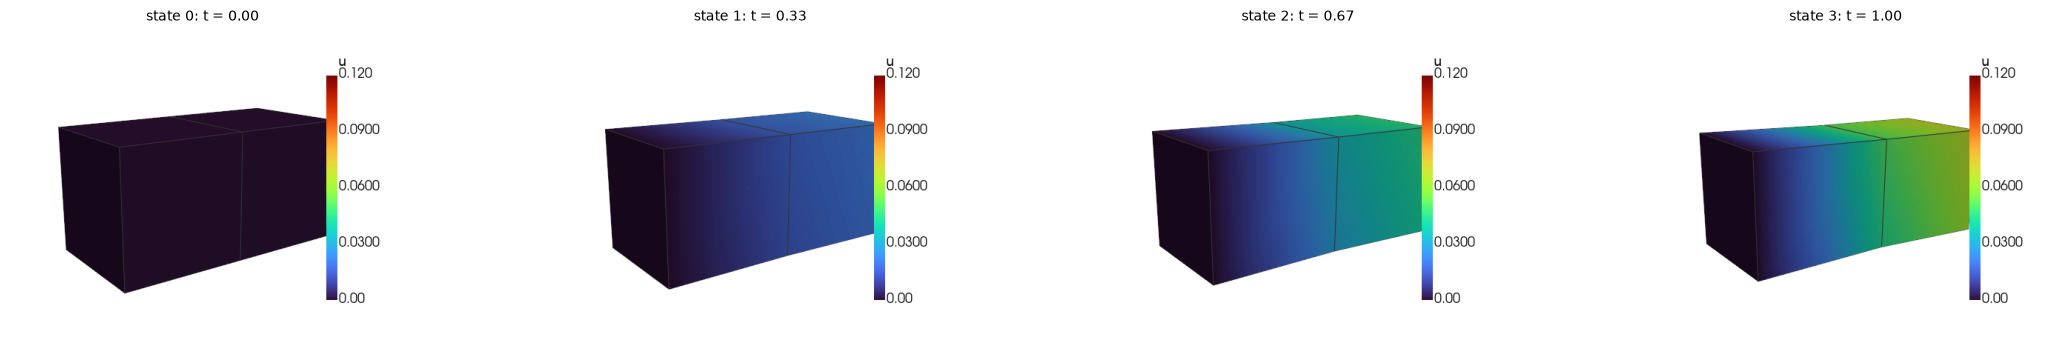

In [9]:
items = []
for k, t in enumerate(mp.xplt.time_values(run)):
    state = mp.read(run, time_step=k)
    u = state.point_data['displacement']
    solid = mp.Mesh(state.points + 5 * u, state.cells[:2])
    grid = to_grid(solid, point_data={'|u|': np.linalg.norm(u, axis=1)})
    items.append((grid, '|u|', f'state {k}: t = {t:.2f}', (0, 0.12)))
gallery(items, ncols=4, size=(520, 420))

A whole run converts to one `.vtu` per state, on the command line with `meshioplusplus convert run.xplt 'out_{step}.vtu'` or from Python:

In [10]:
target = os.path.join(TMP, 'state_{step}.vtu')
mp.write_sequence(target, mp.read_sequence(run))
print(sorted(f for f in os.listdir(TMP) if f.startswith('state_')))
print(mp.read(os.path.join(TMP, 'state_0003.vtu')).field_data['meshio:time'])

['state_0000.vtu', 'state_0001.vtu', 'state_0002.vtu', 'state_0003.vtu']
[1.]


## What was checked

- **Elmer:** ElmerGrid and ElmerSolver were built from source. gmsh meshes converted by ElmerGrid read back node for node as meshio++'s gmsh reader reads them (tet10, hex20, hex27, wedge15). Directories written by meshio++ are re-read by ElmerGrid without a warning, and ElmerSolver solves the heat equation on them to the same answer as on ElmerGrid's own conversion. ElmerGrid's partitions, plain and with halos, merge back into the serial mesh.
- **FEBio:** FEBio 4.12 was built from source. The fixtures are read by FEBio itself. The displacement read from its plot files equals its own `node_data` log to float32 precision at every state, and febio-python's reader gives identical data for its samples.

See the [Elmer](../../doc/formats/elmer.md), [FEBio input](../../doc/formats/febio.md) and [FEBio plot file](../../doc/formats/xplt.md) pages.